# The

In [1]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import shutil
import kagglehub

c:\Pranav Files\College Work\CSC 487\Final\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Grab data from csv, import to dataframe, split into features and labels

In [2]:
# If dataset not downloaded
path = kagglehub.dataset_download("priyamchoksi/credit-card-transactions-dataset")
print("Path to dataset files:", path)

# move/copy the csv to current directory
for file in os.listdir(path):
    if file.endswith('.csv'):
        source_file = os.path.join(path, file)
        target_file = 'credit_card_transactions.csv'
        if not os.path.exists(target_file):
            shutil.copy(source_file, target_file)
            print(f"Copied {file} to {target_file}")
        else:
            print(f"{target_file} already exists.")
        break


Path to dataset files: C:\Users\Pranav Krishna\.cache\kagglehub\datasets\priyamchoksi\credit-card-transactions-dataset\versions\1
credit_card_transactions.csv already exists.


In [3]:
df = pd.read_csv("credit_card_transactions.csv")

X = df.loc[:, df.columns != "is_fraud"].select_dtypes(include=np.number)
y = df["is_fraud"]

X, y


(         Unnamed: 0               cc_num     amt    zip      lat      long  \
 0                 0     2703186189652095    4.97  28654  36.0788  -81.1781   
 1                 1         630423337322  107.23  99160  48.8878 -118.2105   
 2                 2       38859492057661  220.11  83252  42.1808 -112.2620   
 3                 3     3534093764340240   45.00  59632  46.2306 -112.1138   
 4                 4      375534208663984   41.96  24433  38.4207  -79.4629   
 ...             ...                  ...     ...    ...      ...       ...   
 1296670     1296670       30263540414123   15.56  84735  37.7175 -112.4777   
 1296671     1296671     6011149206456997   51.70  21790  39.2667  -77.5101   
 1296672     1296672     3514865930894695  105.93  88325  32.9396 -105.8189   
 1296673     1296673     2720012583106919   74.90  57756  43.3526 -102.5411   
 1296674     1296674  4292902571056973207    4.30  59871  45.8433 -113.8748   
 
          city_pop   unix_time  merch_lat  merch_l

## Remove bad values and check for empty values

In [4]:
bad = X.isna().any(axis=1)
X = X[~bad]
y = y[~bad]

na_x = X.isna().sum(axis=0)
na_y = y.isna().sum(axis=0)

print(na_x, na_y)

Unnamed: 0       0
cc_num           0
amt              0
zip              0
lat              0
long             0
city_pop         0
unix_time        0
merch_lat        0
merch_long       0
merch_zipcode    0
dtype: int64 0


## Turning them into np arrays

In [5]:

X = X.values.astype('float32')
y = y.values.astype('int64')

## Convert to Torch tensors

In [5]:
# lster on

## Convert to tensor dataset, train test split

In [6]:
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

#tryna avoid data leakage
avg = X_train.mean(axis=0, keepdims=True)
stdev = X_train.std(axis=0, keepdims=True)

X_train = (X_train - avg) / stdev
X_test = (X_test - avg) / stdev


X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).long()
X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).long()

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=2048, shuffle=True)
test_loader = DataLoader(test_data, batch_size=2048, shuffle=False)

c:\Pranav Files\College Work\CSC 487\Final\.venv\Lib\site-packages\numpy\_core\_methods.py:201: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


## Model Architecture

In [7]:
device = 'cpu'
if(torch.backends.mps.is_available()):
    print("Using mps")
    device = 'mps'
elif(torch.cuda.is_available()):
    print("Using cuda")
    device = 'cuda'
else:
    print("Using CPU")

linear_model = torch.nn.Sequential(
    torch.nn.Linear(11, 512),
    torch.nn.GELU(),
    torch.nn.Linear(512, 2048),
    torch.nn.GELU(),
    torch.nn.Linear(2048, 1024),
    torch.nn.GELU(),
    torch.nn.Linear(1024, 256),
    torch.nn.GELU(),
    torch.nn.Linear(256, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 2)
).to(device)

loss_fn = torch.nn.CrossEntropyLoss()
lr = 3e-4
opt = torch.optim.AdamW(linear_model.parameters(), lr=lr)

Using cuda


In [8]:
for epoch in range(25):
    for batch in tqdm(train_loader, desc=f'Epoch: {epoch}'):
        X_batch, y_batch = batch
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = linear_model(X_batch)
        loss = loss_fn(pred, y_batch)
        opt.zero_grad()
        loss.backward()
        opt.step()

Epoch: 24: 100%|██████████| 430/430 [00:10<00:00, 40.03it/s]


Predicting...: 100%|██████████| 108/108 [00:01<00:00, 82.77it/s]


Accuracy: 0.9945307780013718


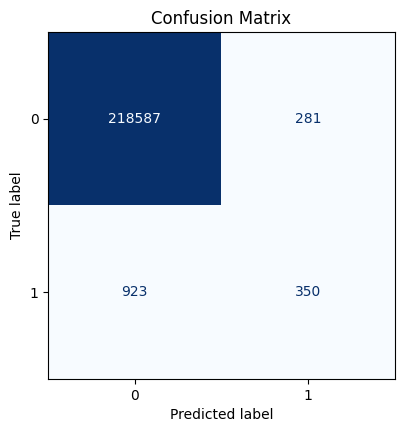

In [9]:
linear_model.eval()

correct = 0
total = 0

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in tqdm(test_loader, desc="Predicting..."):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = linear_model(X_batch)
        predicted_labels = pred.argmax(dim=1)

        y_true.append(y_batch.cpu())
        y_pred.append(predicted_labels.cpu())

        correct += (predicted_labels == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy}")

# Confusion matrix (sklearn)
y_true = torch.cat(y_true).numpy()
y_pred = torch.cat(y_pred).numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Confusion Matrix")
plt.show()

In [10]:
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn) if (tp + fn) else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
total_fraud = y_test.sum()

print(
    f"total fraud: {total_fraud}\n"
    f"true positives: {tp}\n"
    f"true negatives: {tn}\n"
    f"false positives: {fp}\n"
    f"false negatives: {fn}\n"
    f"precision: {precision}\n"
    f"recall: {recall}\n"
    f"f1: {f1}\n"
    f"% of fraudulent transactions in test set classified incorrectly: {fn / total_fraud}"
)

total fraud: 1273
true positives: 350
true negatives: 218587
false positives: 281
false negatives: 923
precision: 0.554675118858954
recall: 0.2749410840534171
f1: 0.36764705882352944
% of fraudulent transactions in test set classified incorrectly: 0.725058913230896
